# Client Clustering and Profile Analysis

The goal of this notebook is to group our 370 clients based on their consumption behavior (patterns) rather than their total volume. This allows us to train specialized models for specific groups (e.g., industrial vs. residential).

## 1. Imports

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Hourly Profile Aggregation
We calculate the mean consumption for each of the 24 hours of the day across the entire dataset for every client. This results in a 370x24 matrix, where each row represents a client's "average day."

In [2]:
# Load the parquet file generated in the preprocessing step
print("Loading processed data...")
df = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

# We aggregate consumption by ClientID and Hour to get an average 24-hour profile for each client.
print("Creating average hourly profiles...")
profiles = df.groupby(['ClientID', 'Hour'], observed=True)['Consumption'].mean().unstack()

Loading processed data...
Creating average hourly profiles...


## 3. Scaling by Row
Standardization is vital here. By applying a Min-Max scaler to each individual client, we remove the "volume" effect. This allows the K-Means algorithm to group a small shop and a large supermarket together if they both share a "9-to-5" consumption signature.

Normalizing profiles...
Calculating inertia for the Elbow Method...


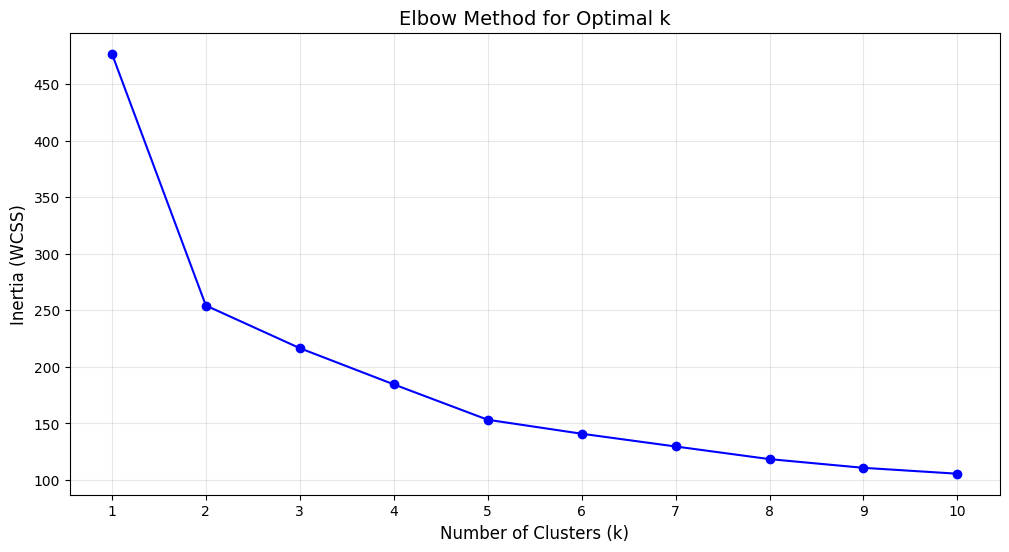

In [3]:
# Scaling client's profile between 0 and 1 in order to cluster by 'behavior shape' (e.g., peak at night vs peak at noon) instead of 'magnitude' (e.g., 10kW house vs 10,000kW factory).
print("Normalizing profiles...")
scaler = MinMaxScaler()
# We transpose because MinMaxScaler scales columns, but we want to scale rows (clients)
profiles_scaled = scaler.fit_transform(profiles.T).T

# Initialize an empty list to store the inertia (Within-Cluster Sum of Squares)
inertia = []
K_range = range(1, 11)  # Testing from 1 to 10 clusters

print("Calculating inertia for the Elbow Method...")

# Loop through each K value
for k in K_range:
    # Use the same parameters (random_state, n_init) as your main clustering
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(profiles_scaled)
    
    # Inertia is the sum of squared distances of samples to their closest cluster center
    inertia.append(model.inertia_)

# 3. Plot the results
plt.figure(figsize=(12, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# K-Means Clustering
n_clusters = 5
print(f"Running K-Means with {n_clusters} clusters...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(profiles_scaled)

# Create a mapping between ClientID and their assigned Cluster
mapping = pd.DataFrame({
    'ClientID': profiles.index, 
    'Cluster': cluster_labels
})

Running K-Means with 5 clusters...


## 4. Interpretation
The resulting plot helps us identify consumer types:

- **Cluster 0 (Blue - 14 clients)**: Night-Shift Industrial. This unique group shows peak consumption from midnight to 6:00 AM, with a significant drop during daylight hours.

- **Cluster 1 (Orange - 81 clients)**: Standard Daytime Business. Features a steady rise starting at 8:00 AM, peaking in the afternoon, and maintaining high activity until late evening (around 9:00 PM).

- **Cluster 2 (Green - 78 clients)**: Late Evening Residential. This group shows a massive spike starting at 7:00 PM and peaking at 9:00 PM, likely representing residential areas with high night-time activity.

- **Cluster 3 (Red - 34 clients)**: Split-Shift/Siesta Profile. These clients have a sharp peak at noon followed by a visible dip at 2:00 PM, a classic "siesta" signature common in Portuguese commercial districts.

- **Cluster 4 (Purple - 163 clients)**: General Commercial/Residential. Representing nearly half the clients, this cluster follows a standard "early rise" profile with high, sustained consumption from 10:00 AM through 8:00 PM.

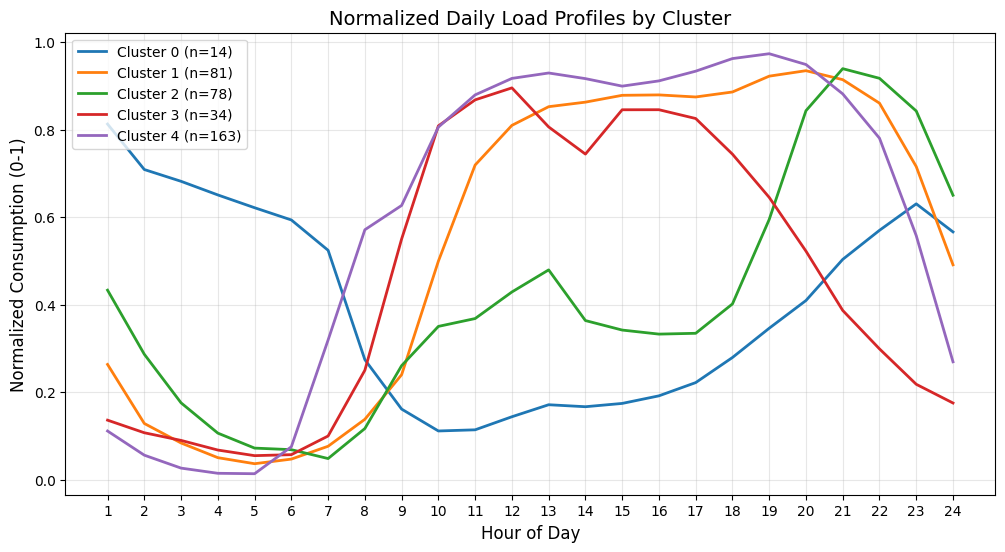

In [5]:
# This plot shows the "typical day" for each group of clients.
plt.figure(figsize=(12, 6))
for i in range(n_clusters):
    # Calculate the mean profile for each cluster
    cluster_mean = profiles_scaled[cluster_labels == i].mean(axis=0)
    plt.plot(range(1, 25), cluster_mean, label=f'Cluster {i} (n={sum(cluster_labels == i)})', linewidth=2)

plt.title('Normalized Daily Load Profiles by Cluster', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Normalized Consumption (0-1)', fontsize=12)
plt.xticks(range(1, 25))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
print("Saving cluster mapping to '../Datasets/client_clusters.csv'...")
mapping.to_csv('../Datasets/client_clusters.csv', index=False)

Saving cluster mapping to '../Datasets/client_clusters.csv'...


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Calculate the mean consumption per client (if not already done)
client_means = df_long.groupby('ClientID', observed=True)['Consumption'].mean().reset_index()
client_means.rename(columns={'Consumption': 'Mean_Consumption'}, inplace=True)
client_means['Log_Mean'] = np.log1p(client_means['Mean_Consumption'])

# 2. Apply K-Means Clustering for 5 segments
print("Applying 1D K-Means (k=5) to find natural consumption boundaries...")
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
client_means['Cluster_ID'] = kmeans_5.fit_predict(client_means[['Log_Mean']])

# 3. Map Cluster IDs to human-readable labels
# We sort the centroids to logically assign labels from smallest to largest
cluster_centers = client_means.groupby('Cluster_ID')['Mean_Consumption'].mean().sort_values()
labels = ['Micro', 'Light', 'Medium', 'Heavy', 'Mega']

label_mapping = {cluster_centers.index[i]: labels[i] for i in range(5)}
client_means['Consumer_Category'] = client_means['Cluster_ID'].map(label_mapping)

# Convert to a Categorical type to enforce a logical ordering in our plots
client_means['Consumer_Category'] = pd.Categorical(
    client_means['Consumer_Category'], 
    categories=labels, 
    ordered=True
)

# Print the natural boundaries K-Means found
print("\n--- Natural Segments Found (k=5) ---")
for cat in labels:
    cat_data = client_means[client_means['Consumer_Category'] == cat]
    print(f"{cat: <6} consumers: {len(cat_data):>3} clients | Range: {cat_data['Mean_Consumption'].min():>8.2f} to {cat_data['Mean_Consumption'].max():>8.2f} kW")

# 4. Plotting the Distributions (Linear vs Log)
# Set up a custom color palette for the 5 categories
custom_palette = {'Micro': '#3498db', 'Light': '#2ecc71', 'Medium': '#f1c40f', 'Heavy': '#e67e22', 'Mega': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Linear Scale (Raw Data)
sns.histplot(
    data=client_means, 
    x='Mean_Consumption', 
    hue='Consumer_Category', 
    palette=custom_palette,
    bins=1000,
    element='step',
    alpha=0.6,
    ax=axes[0]
)
limite_max = client_means['Mean_Consumption'].quantile(0.95) # Mostra il 95% dei clienti
axes[0].set_xlim(0, limite_max)
axes[0].set_title('Client Size Distribution (Linear Scale)', fontsize=14)
axes[0].set_xlabel('Average Consumption (kW)', fontsize=12)
axes[0].set_ylabel('Number of Clients', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Subplot 2: Log Scale
sns.histplot(
    data=client_means, 
    x='Mean_Consumption', 
    hue='Consumer_Category', 
    palette=custom_palette,
    log_scale=True, 
    bins=40,
    element='step',
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Client Size Distribution (Log Scale)', fontsize=14)
axes[1].set_xlabel('Average Consumption (kW) - Log Scale', fontsize=12)
axes[1].set_ylabel('Number of Clients', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Export the mapping to merge later in modeling
client_means[['ClientID', 'Consumer_Category']].to_csv('../Datasets/client_size_categories.csv', index=False)

NameError: name 'df_long' is not defined